In [1]:
# Imports
import sys
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

In [2]:
# CD-NLGSSM imports
from cd_dynamax import make_key_sequence
from cd_dynamax.src.utils.experiment_utils import *
from cd_dynamax.src.utils.simulation_utils import filter_and_forecast
from cd_dynamax.src.utils.demo_utils import sample_t_emissions

# Python plotting import
sys.path.append("../scripts")
from filter_forecast_plotting_utils import (
    data_plotter,
    plot_filter_then_forecast_state_results,
)
from parameter_learning_plotting_utils import (
    learnable_params_to_1d_df,
    plot_mll_learning_curve,
    plot_param_sequences
)

# Set default config path
config_path = "../configs/"

## Define the linear Gaussian continuous-discrete state space model


We generate data from a linear Gaussian continuous-discrete state space model:

\begin{align*}
x_0 &\sim N(\mu_0, Q_0) \\
\frac{d x}{d t} &= A_t x(t) + b_t + L_t \frac{d w}{d t} \\
y(t_k) &= H_t x(t_k) + d_t + r_k \\
r_k &\sim N(0,R),
\end{align*}

Brownian motion process $w(t)$ with covariance $Q$, and where observations are made at discrete time points $t_k$.
Namely, we observe noisy data according to H, sampled at irregular time intervals.

In [3]:
# Default CD-LGSSM model definition in config file
default_cdlgssm_config_model = "model/cdlgssm"

In [4]:
# If you want to change defaults, define parameters dictionary
state_dim = 3
emission_dim = 3
true_cdlgssm_model_def = {
    'model.state_dim': state_dim,
    'model.emission_dim': emission_dim,
    'initial.values.dynamics_weights': {
        "params": -0.1*jnp.eye(state_dim),
        "props": None # Let us use the default parameter properties
    },
}


In [5]:
# Create and initialize the CD-NLGSSM model
true_model, true_params, true_props = create_cddynamax_model_from_config(
    config_path=config_path,
    true_model_config_file=default_cdlgssm_config_model,
    overrides=true_cdlgssm_model_def,
)

### Simulate data using true CD-LGSSM model

In [6]:
# Simulate emission times
keys = make_key_sequence(0)
t_emissions = sample_t_emissions(
    start=0.0,
    stop=25.0,
    dt=0.01,
    regular=False,
    key=next(keys)
)

# Simulate data using true parameters (observed at times t_emissions)
# Note that default SDE diffeqsolve settings solve using dfx.Heun() with dfx.ConstantStepSize() and dt0=0.01 step size.
states, emissions = true_model.sample(
    params=true_params,
    key=next(keys),
    num_timesteps=len(t_emissions),
    t_emissions=t_emissions,
    transition_type="path",
)

[make_t_emissions] Generated 2500 points from 0.0 to 25.0 with avg step ~0.0100
[make_t_emissions] Smallest time step = 0.000002
Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete linear Gaussian SSM path


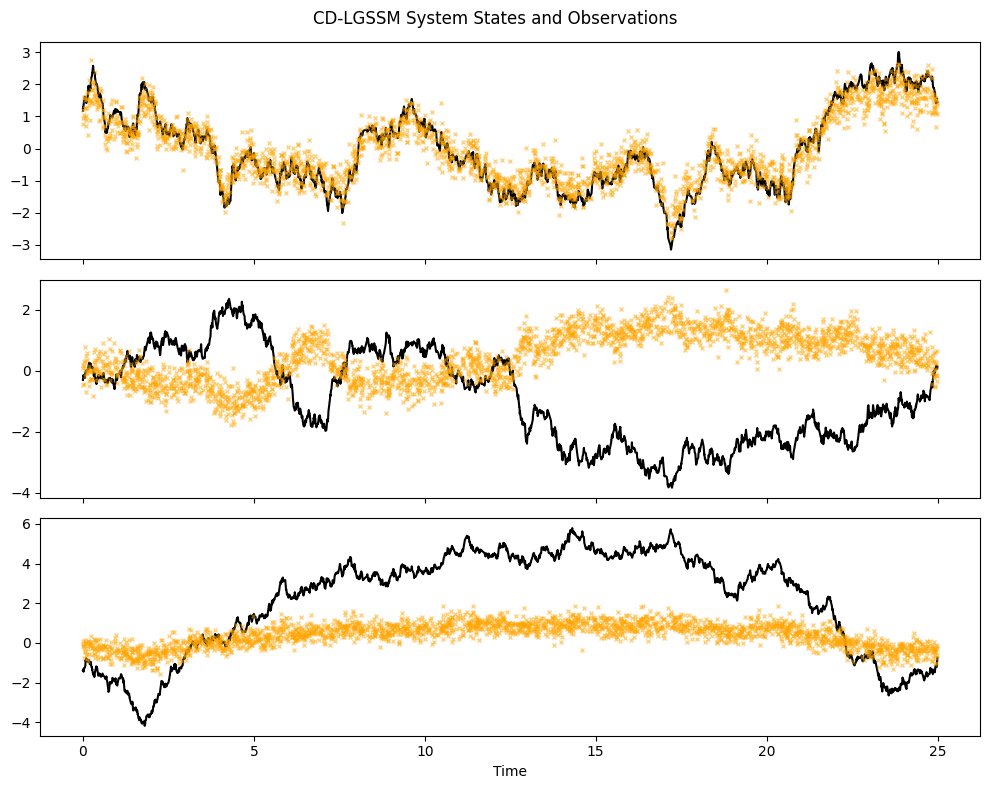

In [7]:
# Plot the results in a subplot with 3 rows, with observations overlaid in first emission_dims rows
fig, axes = plt.subplots(
    true_model.state_dim,
    1,
    figsize=(10, 8),
    sharex=True
)
state_labels = ['x', 'y', 'z']
for d in range(true_model.state_dim):
    ### True data
    data_plotter(
        ax=axes[d],
        t_idx=t_emissions,
        states=states[:, d],
        state_label=state_labels[d],
        state_style={'color': 'black', 'linestyle': '-', 'linewidth': 1.5},
        emissions=emissions[:, d] if d < emissions.shape[1] else None,
        emission_label='True Observation' if d < emissions.shape[1] else None,
        emissions_style={'color': 'orange', 'linestyle': 'None', 'marker': 'x', 'markersize': 3, 'alpha': 0.5},
        plot_observations=True and d < emissions.shape[1],
    )
axes[-1].set_xlabel('Time')
plt.suptitle('CD-LGSSM System States and Observations')
plt.tight_layout()
plt.show()

## Fitting another CD-LGSSM model to the data

### Learnable model definition 

In [8]:
# New CD-LGSSM model definition in config file
learnable_cdlgssm_config_model = "model/cdlgssm_fit_to_data"

# If desired, we can override the initial parameters here
learnable_cdlgssm_model_def = {
    'initial.values.dynamics_weights': {
        "params": 0.8*jnp.eye(state_dim), # Initialized to identity
        "props": ParameterProperties(trainable=True) # Let us learn A matrix
    },
    'initial.values.dynamics_diffusion_coefficient': {
        "params": 0.5*jnp.eye(state_dim), # Initialized to identity
        "props": ParameterProperties(trainable=True) # Let us learn the L matrix
    },
}

In [9]:
# Create and initialize the CD-NLGSSM model
learnable_model, learnable_params, learnable_props = create_cddynamax_model_from_config(
    config_path=config_path,
    true_model_config_file=learnable_cdlgssm_config_model,
    overrides=learnable_cdlgssm_model_def,
)

## Fitting: SGD-based optimization of log-likelihood, computed via the Kalman Filter (EKF) 

In [10]:
# Default KF settings are defined in config file
default_kf_config = "filter/kf"

In [11]:
# Figure-out the filtering/smoothing settings from config
kf_hyperparams, kf_info = create_cddynamax_filter_from_config(
    config_path=config_path,
    filter_config_file=default_kf_config,
    overrides={}
)

SGD for log-likelihood maximization

In [12]:
# Load SGD fitting configuration

# Fit configuration file
fit_config_file = "fitting/fit_sgd_cdlgssm"

# Full path to the fit config file
fit_config_filepath = os.path.join(config_path, fit_config_file)

# Check if the config file exists
if not os.path.exists(fit_config_filepath):
    raise FileNotFoundError(f"Configuration file '{fit_config_filepath}' not found.")

# Read the fitting configuration
from configparser import ConfigParser
config = ConfigParser()
config.read(fit_config_filepath)

# For each optimization method specified in the config
optim_configs = config.sections()

In [13]:
# Run SGD for parameter estimation
import optax
if 'sgd' in optim_configs:
    # SGD configuration
    sgd_config = config['sgd']
    # SGD MAP estimation via the cd-dynamax learnable_model's fit_sgd method
    print("\nStarting SGD fitting...")
    fit_results = learnable_model.fit_sgd(
        initial_params = learnable_params,
        props=learnable_props,
        emissions=emissions,
        t_emissions=t_emissions,
        filter_hyperparams=kf_hyperparams,
        inputs=None,
        optimizer=eval(sgd_config.get('optimizer', 'optax.adam(1e-3)')),
        batch_size = sgd_config.getint('batch_size', 1),
        num_epochs = sgd_config.getint('num_epochs', 50),
        shuffle = sgd_config.getboolean('shuffle', False),
        return_param_history = sgd_config.getboolean('return_param_history', False),
        return_grad_history = sgd_config.getboolean('return_grad_history', False),
        key = jr.PRNGKey(sgd_config.getint('key', 0))
    )


Starting SGD fitting...


Organize results for easier plotting

In [14]:
# First element of tuple is the fitted parameters
sgd_fitted_params=fit_results[0]
# Note that fit_sgd returns normalized negative log-likelihoods
# So we multiply it by the number of datapoints in emissions
sgd_loss_history=-fit_results[1] * emissions.size

# Process history outputs if requested
if sgd_config.getboolean('return_param_history', False) and sgd_config.getboolean('return_grad_history', False):
    sgd_fitted_params_history=fit_results[2]
    sgd_fitted_grad_history=fit_results[3]
elif sgd_config.getboolean('return_param_history', False) :
    sgd_fitted_params_history=fit_results[2]
elif sgd_config.getboolean('return_grad_history', False):
    sgd_fitted_grad_history=fit_results[2]

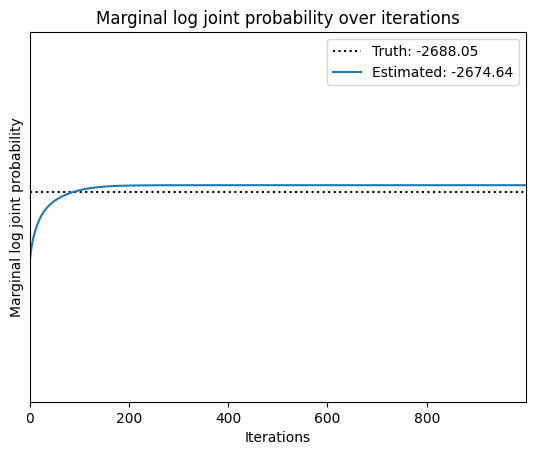

In [15]:
# Plot the marginal log likelihood learning curve
plot_mll_learning_curve(
    true_model = true_model,
    true_params = true_params,
    true_emissions = emissions,
    t_emissions = t_emissions,
    marginal_lls = sgd_loss_history,
    filter_hyperparams=kf_hyperparams,
    plot_save_path=None # Plot here instead of saving
)

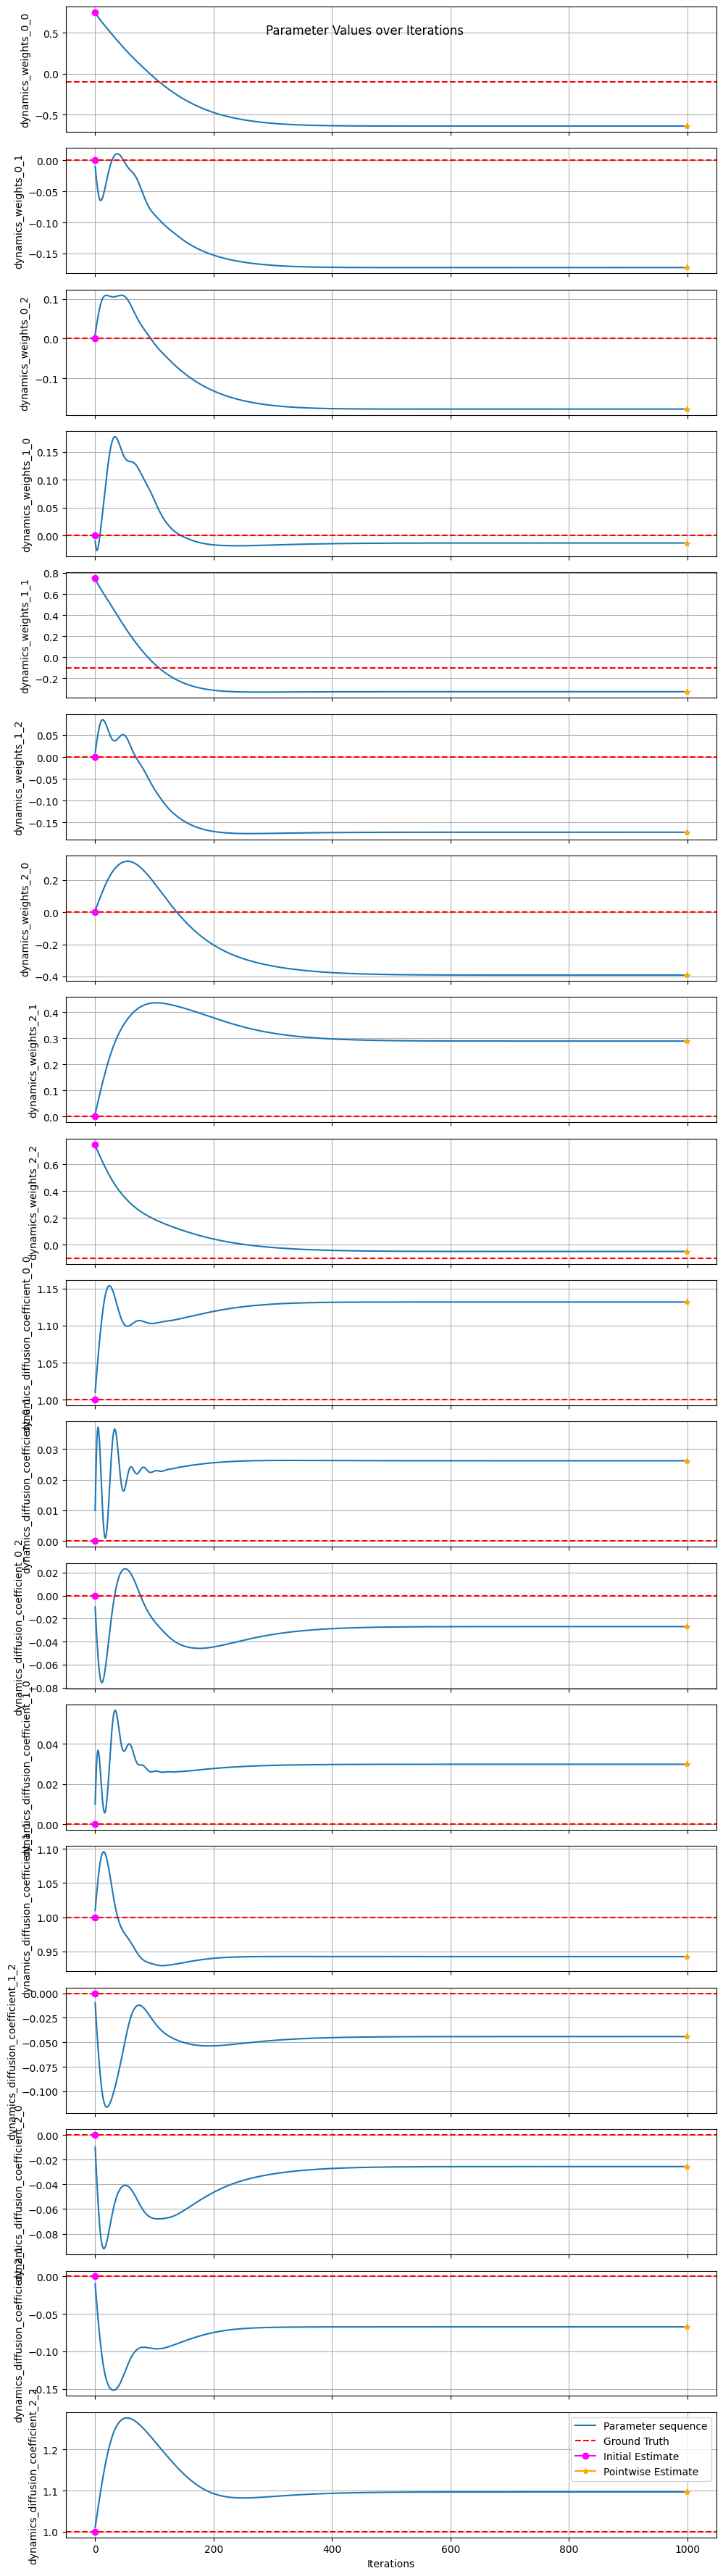

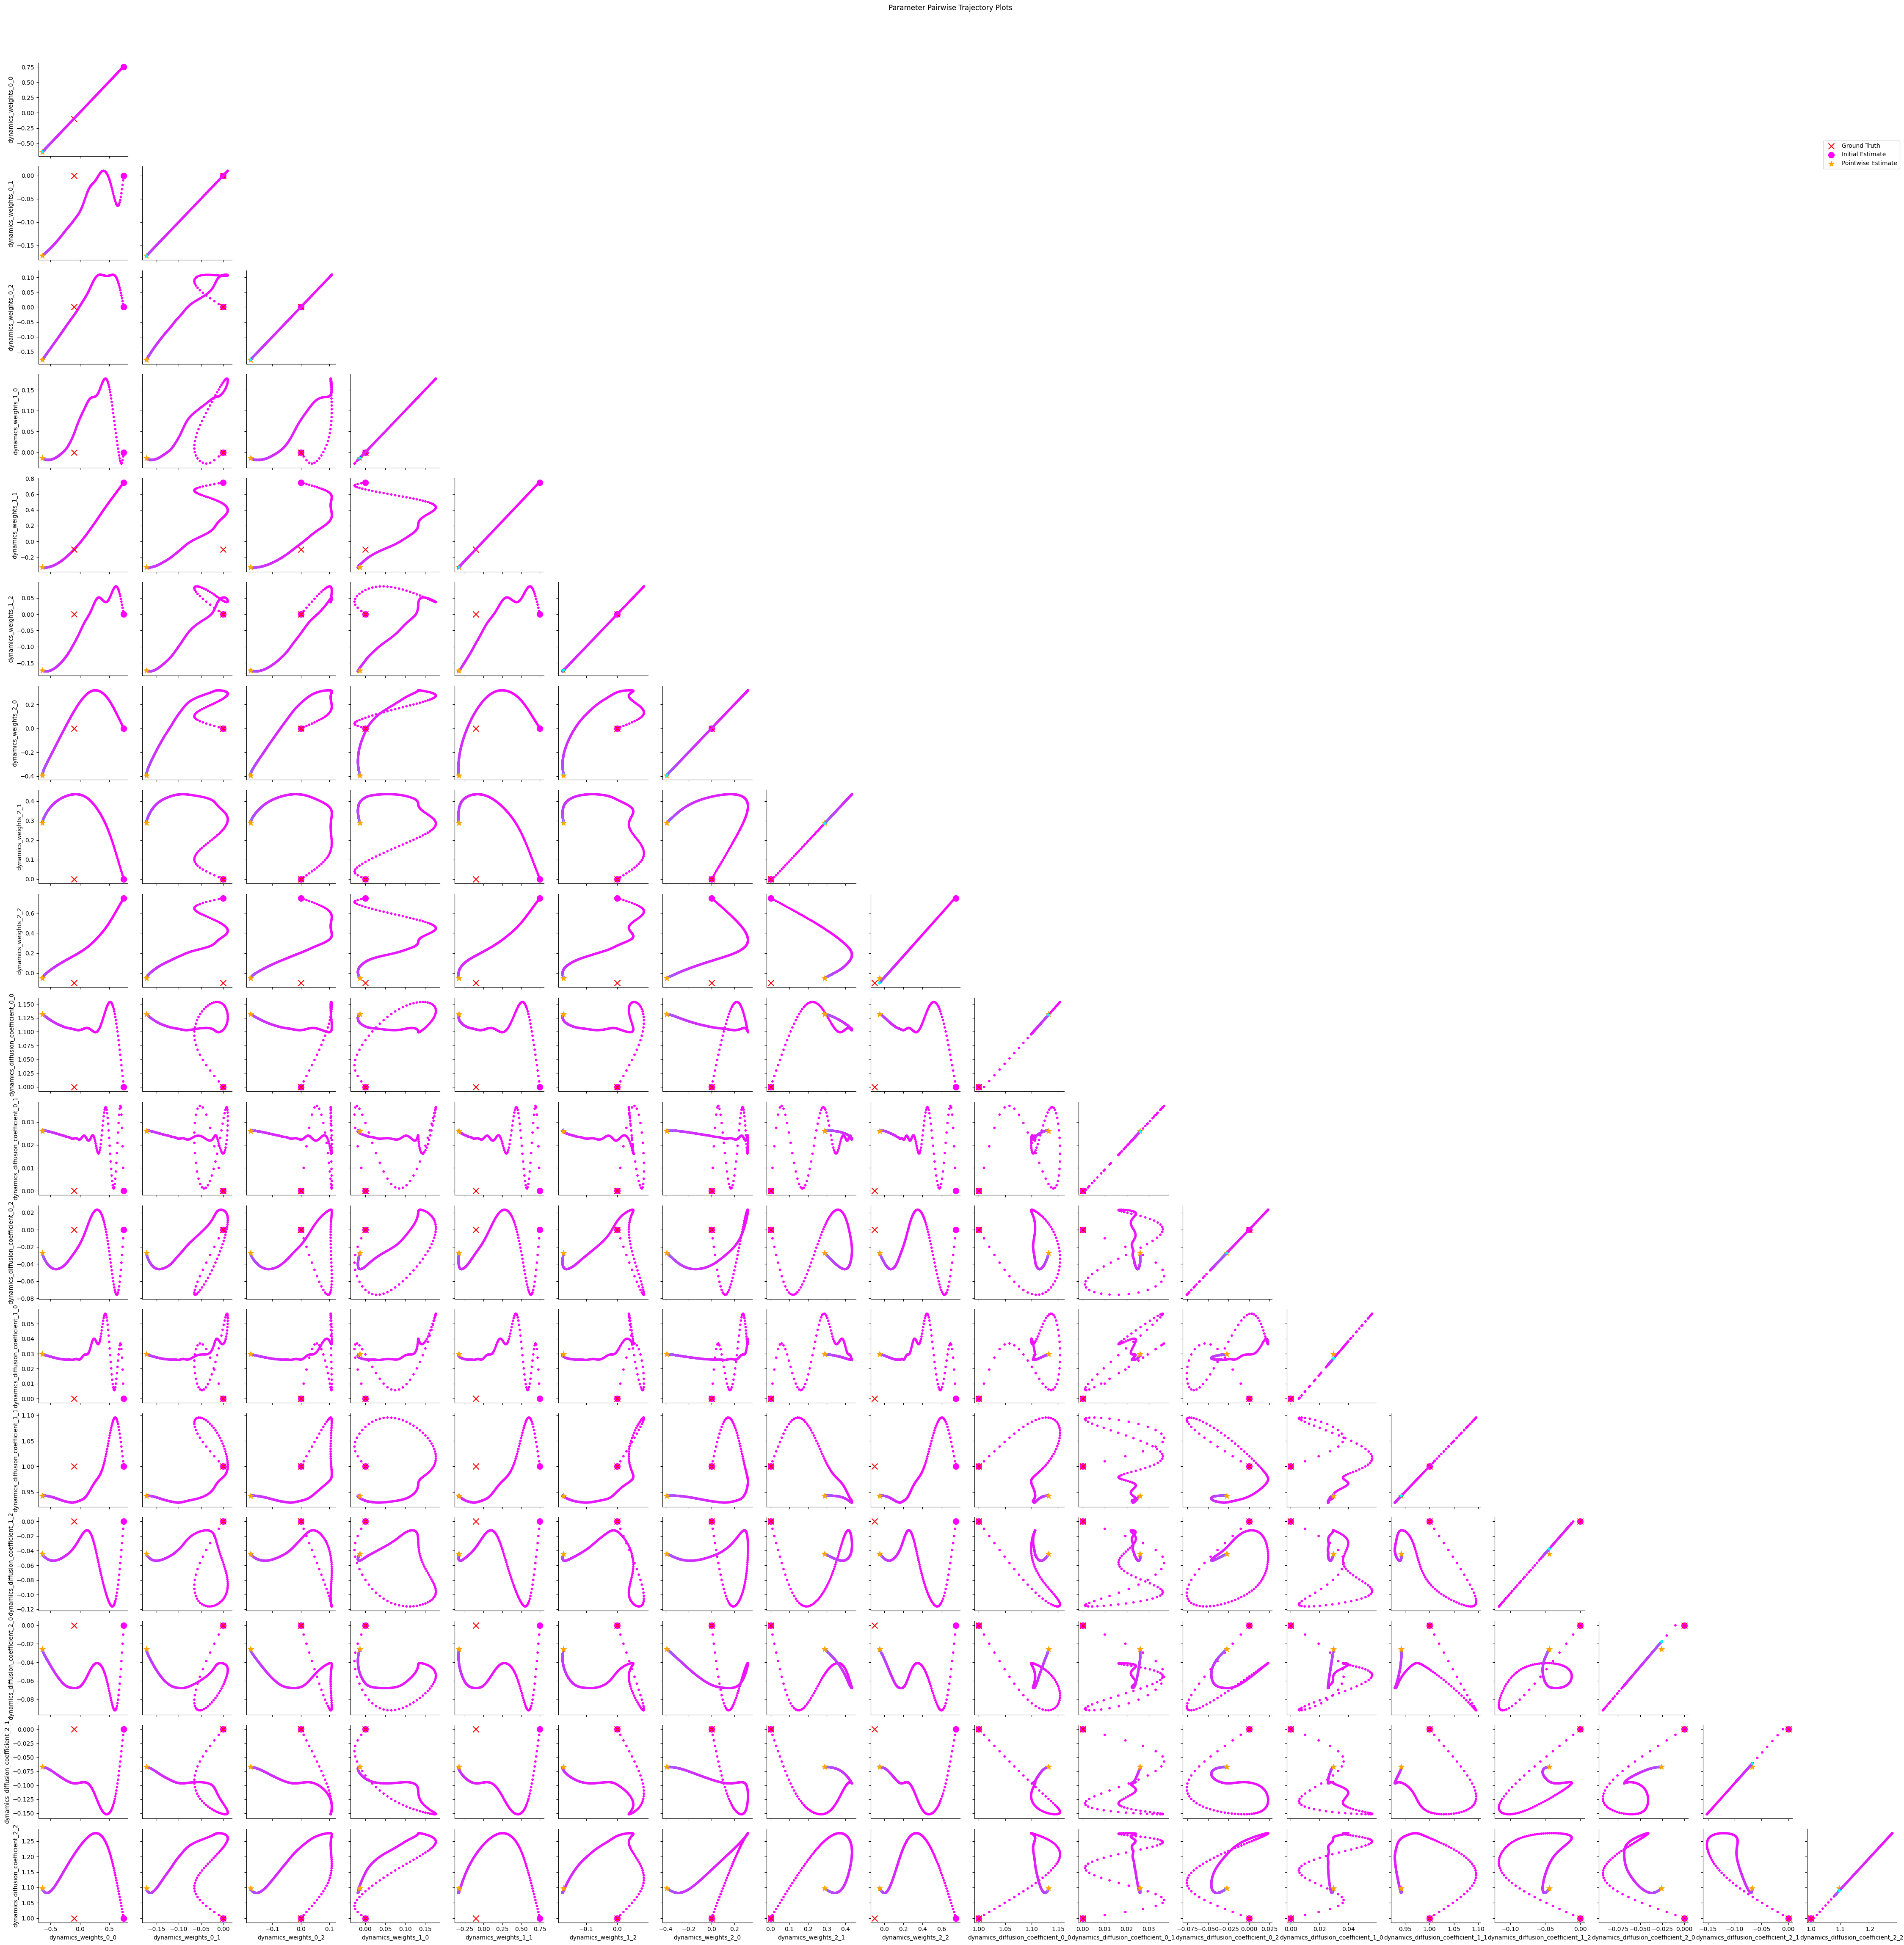

In [16]:
# Plot parameter trajectories over SGD iterations ---translating trees to dataframes
plot_param_sequences(
    param_history=learnable_params_to_1d_df(
        sgd_fitted_params_history, learnable_props, has_batch_dim=True
    ),
    true=learnable_params_to_1d_df(
        true_params, learnable_props
    ),
    init=learnable_params_to_1d_df(
        learnable_params, learnable_props
    ),
    pointwise_estimate=learnable_params_to_1d_df(
        sgd_fitted_params, learnable_props
    ),
    burn_in_frac=0.0,
    pairwise_plots=True,
    plot_save_path=None # Plot here instead of saving
)

## Filter then forecast using true and learned models

We now generate a new test trajectory from the true model, then do filtering and forecasting (using both true and learned models) to evaluate short-term forecasting performance.

In [17]:
# Define a set of time indices for filtering and forecasting
test_t_emissions = sample_t_emissions(
    start=0.0,
    stop=100.0,
    dt=0.01,
    regular=True,
    key=next(keys)
)

[make_t_emissions] Generated 10000 points from 0.0 to 100.0 with avg step ~0.0100
[make_t_emissions] Smallest time step = 0.010000


In [18]:
# Now, generate a new testing trajectory from the true model. 
test_states, test_emissions = true_model.sample(
    params=true_params,
    key=next(keys),
    num_timesteps=len(test_t_emissions),
    t_emissions=test_t_emissions,
    transition_type="path",
)

Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete linear Gaussian SSM path


In [19]:
# Forecasting and filtering on specific range
T0 = 45.0
T_filter_end = 50.0
T_forecast_end = 52.0

### Filtering and Forecasting with the true model 

Note that the diffusion in the true SDE model (combined with the chaotic sensitivies of the Lorenz drift) makes even high-quality forecasts diverge quickly.

In [20]:
print("Running filtering with {filter_name} with True model from T={T0} up to T={T_filter_end} and forecasting up to T={T_forecast_end}.".format(
    filter_name = kf_info['name'] if kf_info is not None and 'name' in kf_info else "the specified filter",
    T0=T0, T_filter_end=T_filter_end, T_forecast_end=T_forecast_end
    )
)

# Perform filtering and forecasting
true_test_kf_filtered, true_test_kf_forecasted, start_idx_filter, stop_idx_filter, start_idx_forecast, stop_idx_forecast = filter_and_forecast(
    model_params=true_params,
    filter_hyperparams=kf_hyperparams,
    t_emissions=test_t_emissions,
    emissions=test_emissions,
    T0=T0,
    T_filter_end=T_filter_end,
    T_forecast_end=T_forecast_end,
)

Running filtering with Kalman Filtering with True model from T=45.0 up to T=50.0 and forecasting up to T=52.0.


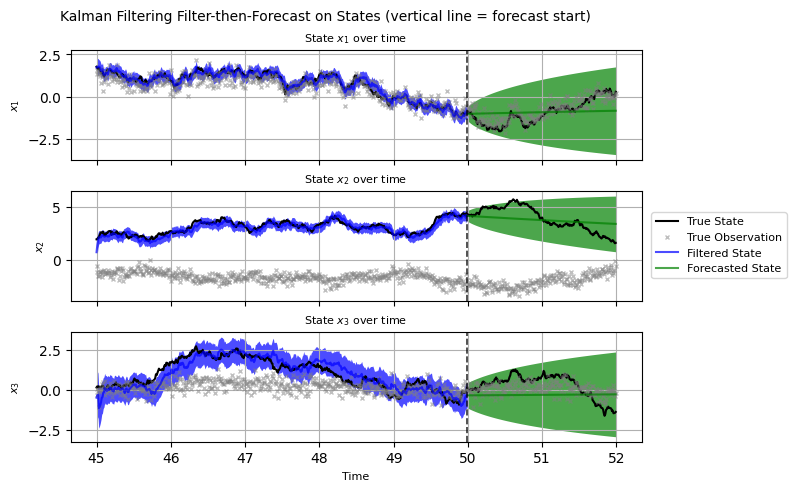

In [21]:
# Plot both filtering and forecasting results
plot_filter_then_forecast_state_results(
    data={
        'states': test_states,
        'emissions': test_emissions,
        't_emissions': test_t_emissions,
    },
    results={
        'filtered': tree_to_dict(true_test_kf_filtered),
        'forecasted': tree_to_dict(true_test_kf_forecasted),
        'start_idx_filter': start_idx_filter,
        'stop_idx_filter': stop_idx_filter,
        'start_idx_forecast': start_idx_forecast,
        'stop_idx_forecast': stop_idx_forecast,
    },
    plot_only_filter_forecast_window=True,
    results_file=None, # Plot here, not save
    filter_info=kf_info,
    plot_uncertainty=True,
    plot_observations=True,
    plot_mse=False,
)

### Filtering and Forecasting with the learned model 

In [22]:
print("Running filtering with {filter_name} with Learned model from T={T0} up to T={T_filter_end} and forecasting up to T={T_forecast_end}.".format(
    filter_name = kf_info['name'] if kf_info is not None and 'name' in kf_info else "the specified filter",
    T0=T0, T_filter_end=T_filter_end, T_forecast_end=T_forecast_end
    )
)

# Perform filtering and forecasting
test_kf_filtered, test_kf_forecasted, start_idx_filter, stop_idx_filter, start_idx_forecast, stop_idx_forecast = filter_and_forecast(
    model_params=sgd_fitted_params,
    filter_hyperparams=kf_hyperparams,
    t_emissions=test_t_emissions,
    emissions=test_emissions,
    T0=T0,
    T_filter_end=T_filter_end,
    T_forecast_end=T_forecast_end,
)

Running filtering with Kalman Filtering with Learned model from T=45.0 up to T=50.0 and forecasting up to T=52.0.


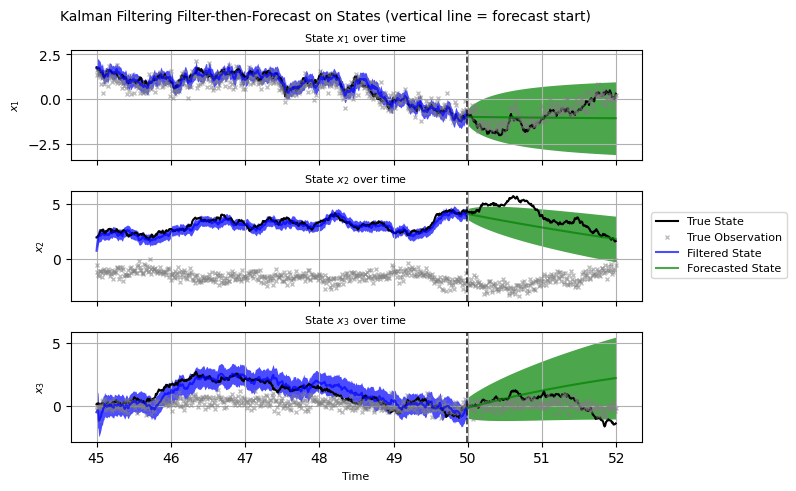

In [23]:
# Plot both filtering and forecasting results
plot_filter_then_forecast_state_results(
    data={
        'states': test_states,
        'emissions': test_emissions,
        't_emissions': test_t_emissions,
    },
    results={
        'filtered': tree_to_dict(test_kf_filtered),
        'forecasted': tree_to_dict(test_kf_forecasted),
        'start_idx_filter': start_idx_filter,
        'stop_idx_filter': stop_idx_filter,
        'start_idx_forecast': start_idx_forecast,
        'stop_idx_forecast': stop_idx_forecast,
    },
    plot_only_filter_forecast_window=True,
    results_file=None, # Plot here, not save
    filter_info=kf_info,
    plot_uncertainty=True,
    plot_observations=True,
    plot_mse=False,
)

### Simulate multiple data-streams using same true CD-LGSSM model

In [24]:
# Number of data-streams to simulate
num_data_streams = 5

# Set the keys
keys = make_key_sequence(2)

# We will be using JAX vmap to simulate multiple data-streams
from jax import vmap

Same t_emissions for all data-streams

In [25]:
# If we want to sample with same t_emissions for all data-streams
t_emissions = sample_t_emissions(
    start=0.0,
    stop=25.0,
    dt=0.01,
    regular=False,
    key=next(keys)
)

num_timesteps = t_emissions.shape[0]

# Then, simulate data using true parameters (observed at times t_emissions)
# Based on cd-dynamax sample_batch method
batch_states, batch_emissions = true_model.sample_batch(
        params = true_params,
        key = next(keys),
        num_sequences = num_data_streams,
        num_timesteps = num_timesteps,
        t_emissions = t_emissions,
        transition_type = "path"
)

[make_t_emissions] Generated 2500 points from 0.0 to 25.0 with avg step ~0.0100
[make_t_emissions] Smallest time step = 0.000012
Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete linear Gaussian SSM path


In [26]:
# Compute log-likelihood of the batch data under the true model
batch_lls = vmap(
    true_model.marginal_log_prob,
    in_axes=(None, 0, None, None)
    )(
        true_params,
        batch_emissions,
        t_emissions,
        kf_hyperparams,
)
print("Per-data-stream log-likelihoods under the true model:", batch_lls)
print("Total log-likelihood under the true model:", batch_lls.sum())
print("Total average log-likelihood under the true model:", batch_lls.mean())


Per-data-stream log-likelihoods under the true model: [-2605.66196518 -2575.92673916 -2624.49531255 -2551.82882247
 -2579.55956918]
Total log-likelihood under the true model: -12937.47240854002
Total average log-likelihood under the true model: -2587.494481708004


Learnable model for the batched data

In [27]:
# Create and initialize a new CD-NLGSSM model for the batched data
new_learnable_model, new_learnable_params, new_learnable_props = create_cddynamax_model_from_config(
    config_path=config_path,
    true_model_config_file=learnable_cdlgssm_config_model,
    overrides=learnable_cdlgssm_model_def,
)

In [28]:
# Run SGD for parameter estimation
import optax
if 'sgd' in optim_configs:
    # SGD configuration
    sgd_config = config['sgd']
    # SGD MAP estimation via the cd-dynamax learnable_model's fit_sgd method
    print("\nStarting SGD fitting...")
    new_fit_results = new_learnable_model.fit_sgd(
        initial_params = new_learnable_params,
        props=new_learnable_props,
        emissions=batch_emissions, # Use batched emissions
        t_emissions=t_emissions,
        filter_hyperparams=kf_hyperparams,
        inputs=None,
        optimizer=eval(sgd_config.get('optimizer', 'optax.adam(1e-3)')),
        batch_size = sgd_config.getint('batch_size', 1),
        num_epochs = sgd_config.getint('num_epochs', 50),
        shuffle = sgd_config.getboolean('shuffle', False),
        return_param_history = sgd_config.getboolean('return_param_history', False),
        return_grad_history = sgd_config.getboolean('return_grad_history', False),
        key = jr.PRNGKey(sgd_config.getint('key', 0))
    )


Starting SGD fitting...


Organize results for easier plotting

In [29]:
# First element of tuple is the fitted parameters
new_sgd_fitted_params=new_fit_results[0]
# Note that fit_sgd returns normalized negative log-likelihoods
# So we multiply it by the number of datapoints in emissions
new_sgd_loss_history=-new_fit_results[1] * batch_emissions.size

# Process history outputs if requested
if sgd_config.getboolean('return_param_history', False) and sgd_config.getboolean('return_grad_history', False):
    new_sgd_fitted_params_history=new_fit_results[2]
    new_sgd_fitted_grad_history=new_fit_results[3]
elif sgd_config.getboolean('return_param_history', False) :
    new_sgd_fitted_params_history=new_fit_results[2]
elif sgd_config.getboolean('return_grad_history', False):
    new_sgd_fitted_grad_history=new_fit_results[2]

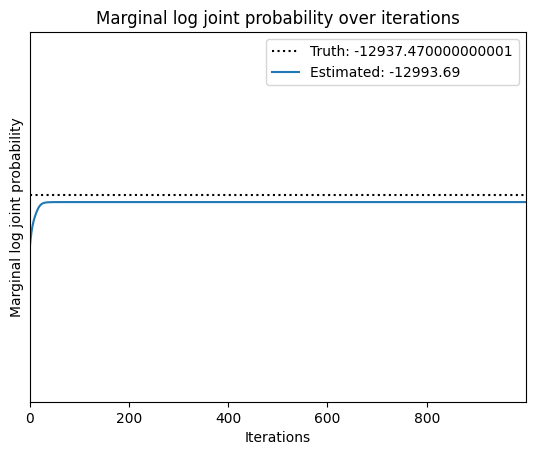

In [30]:
# Plot the marginal log likelihood learning curve
plot_mll_learning_curve(
    true_model = true_model,
    true_params = true_params,
    true_emissions = batch_emissions,
    t_emissions = t_emissions,
    marginal_lls = new_sgd_loss_history,
    filter_hyperparams=kf_hyperparams,
    plot_save_path=None # Plot here instead of saving
)

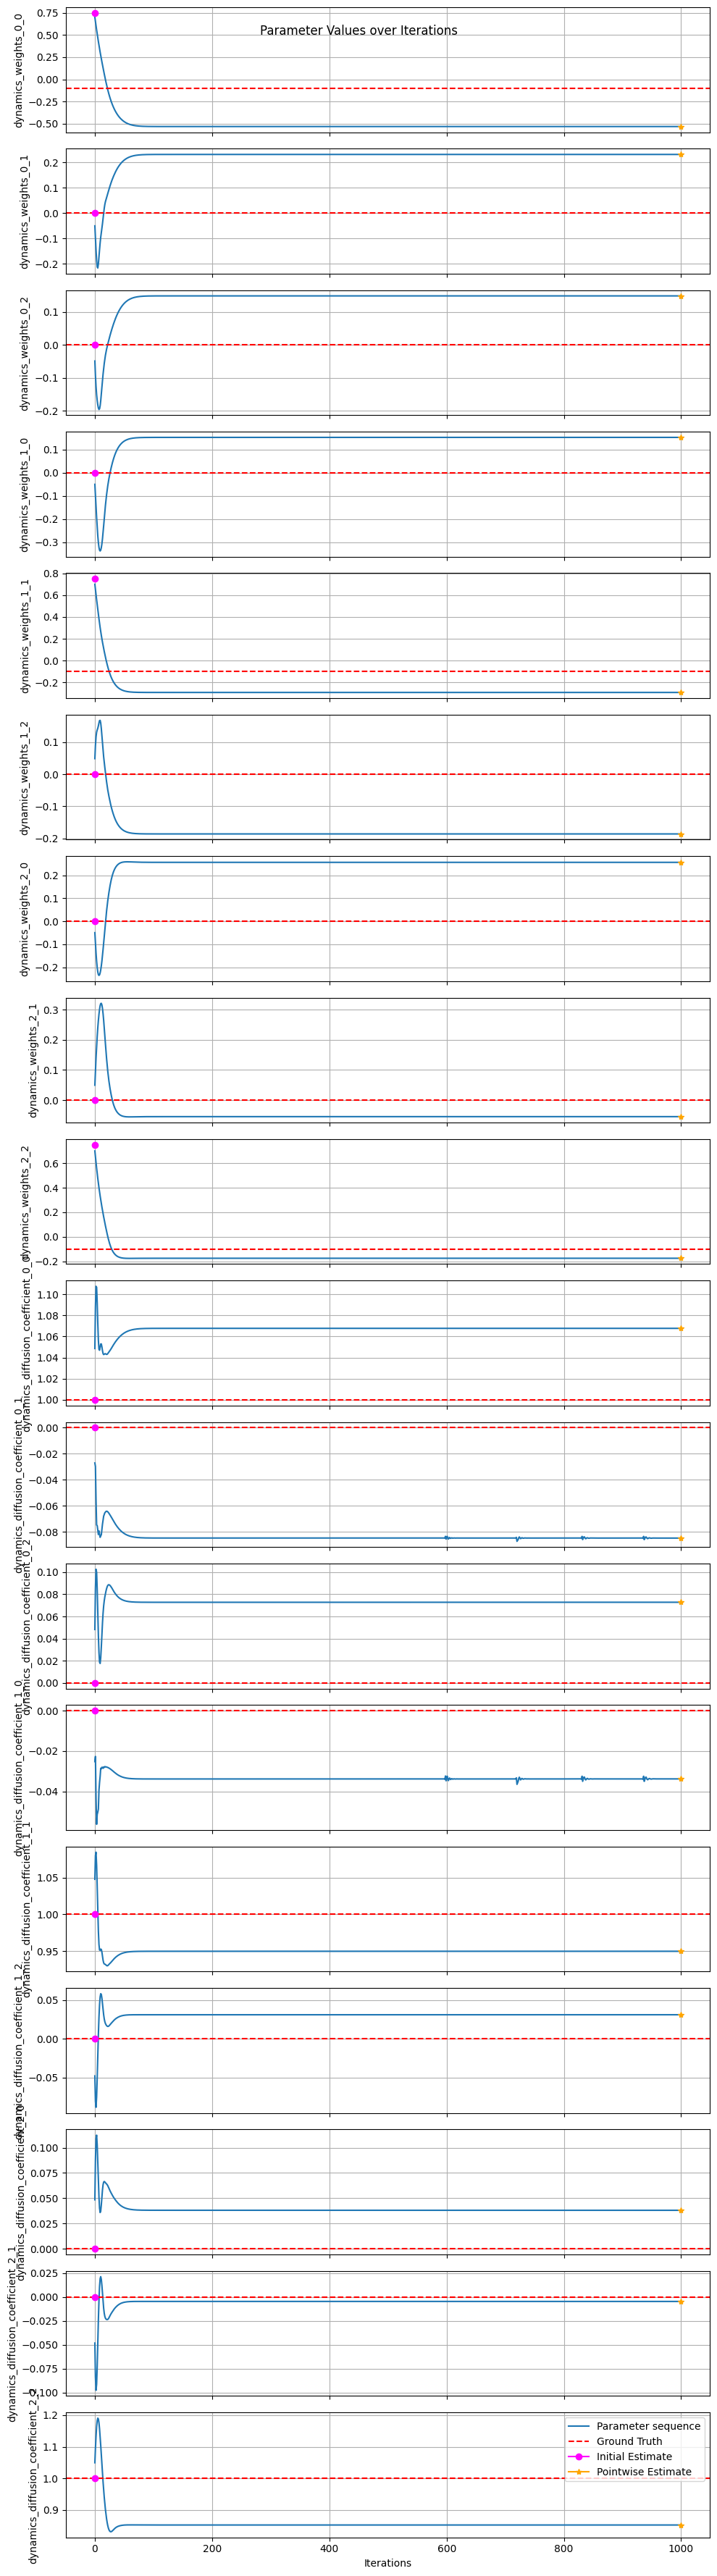

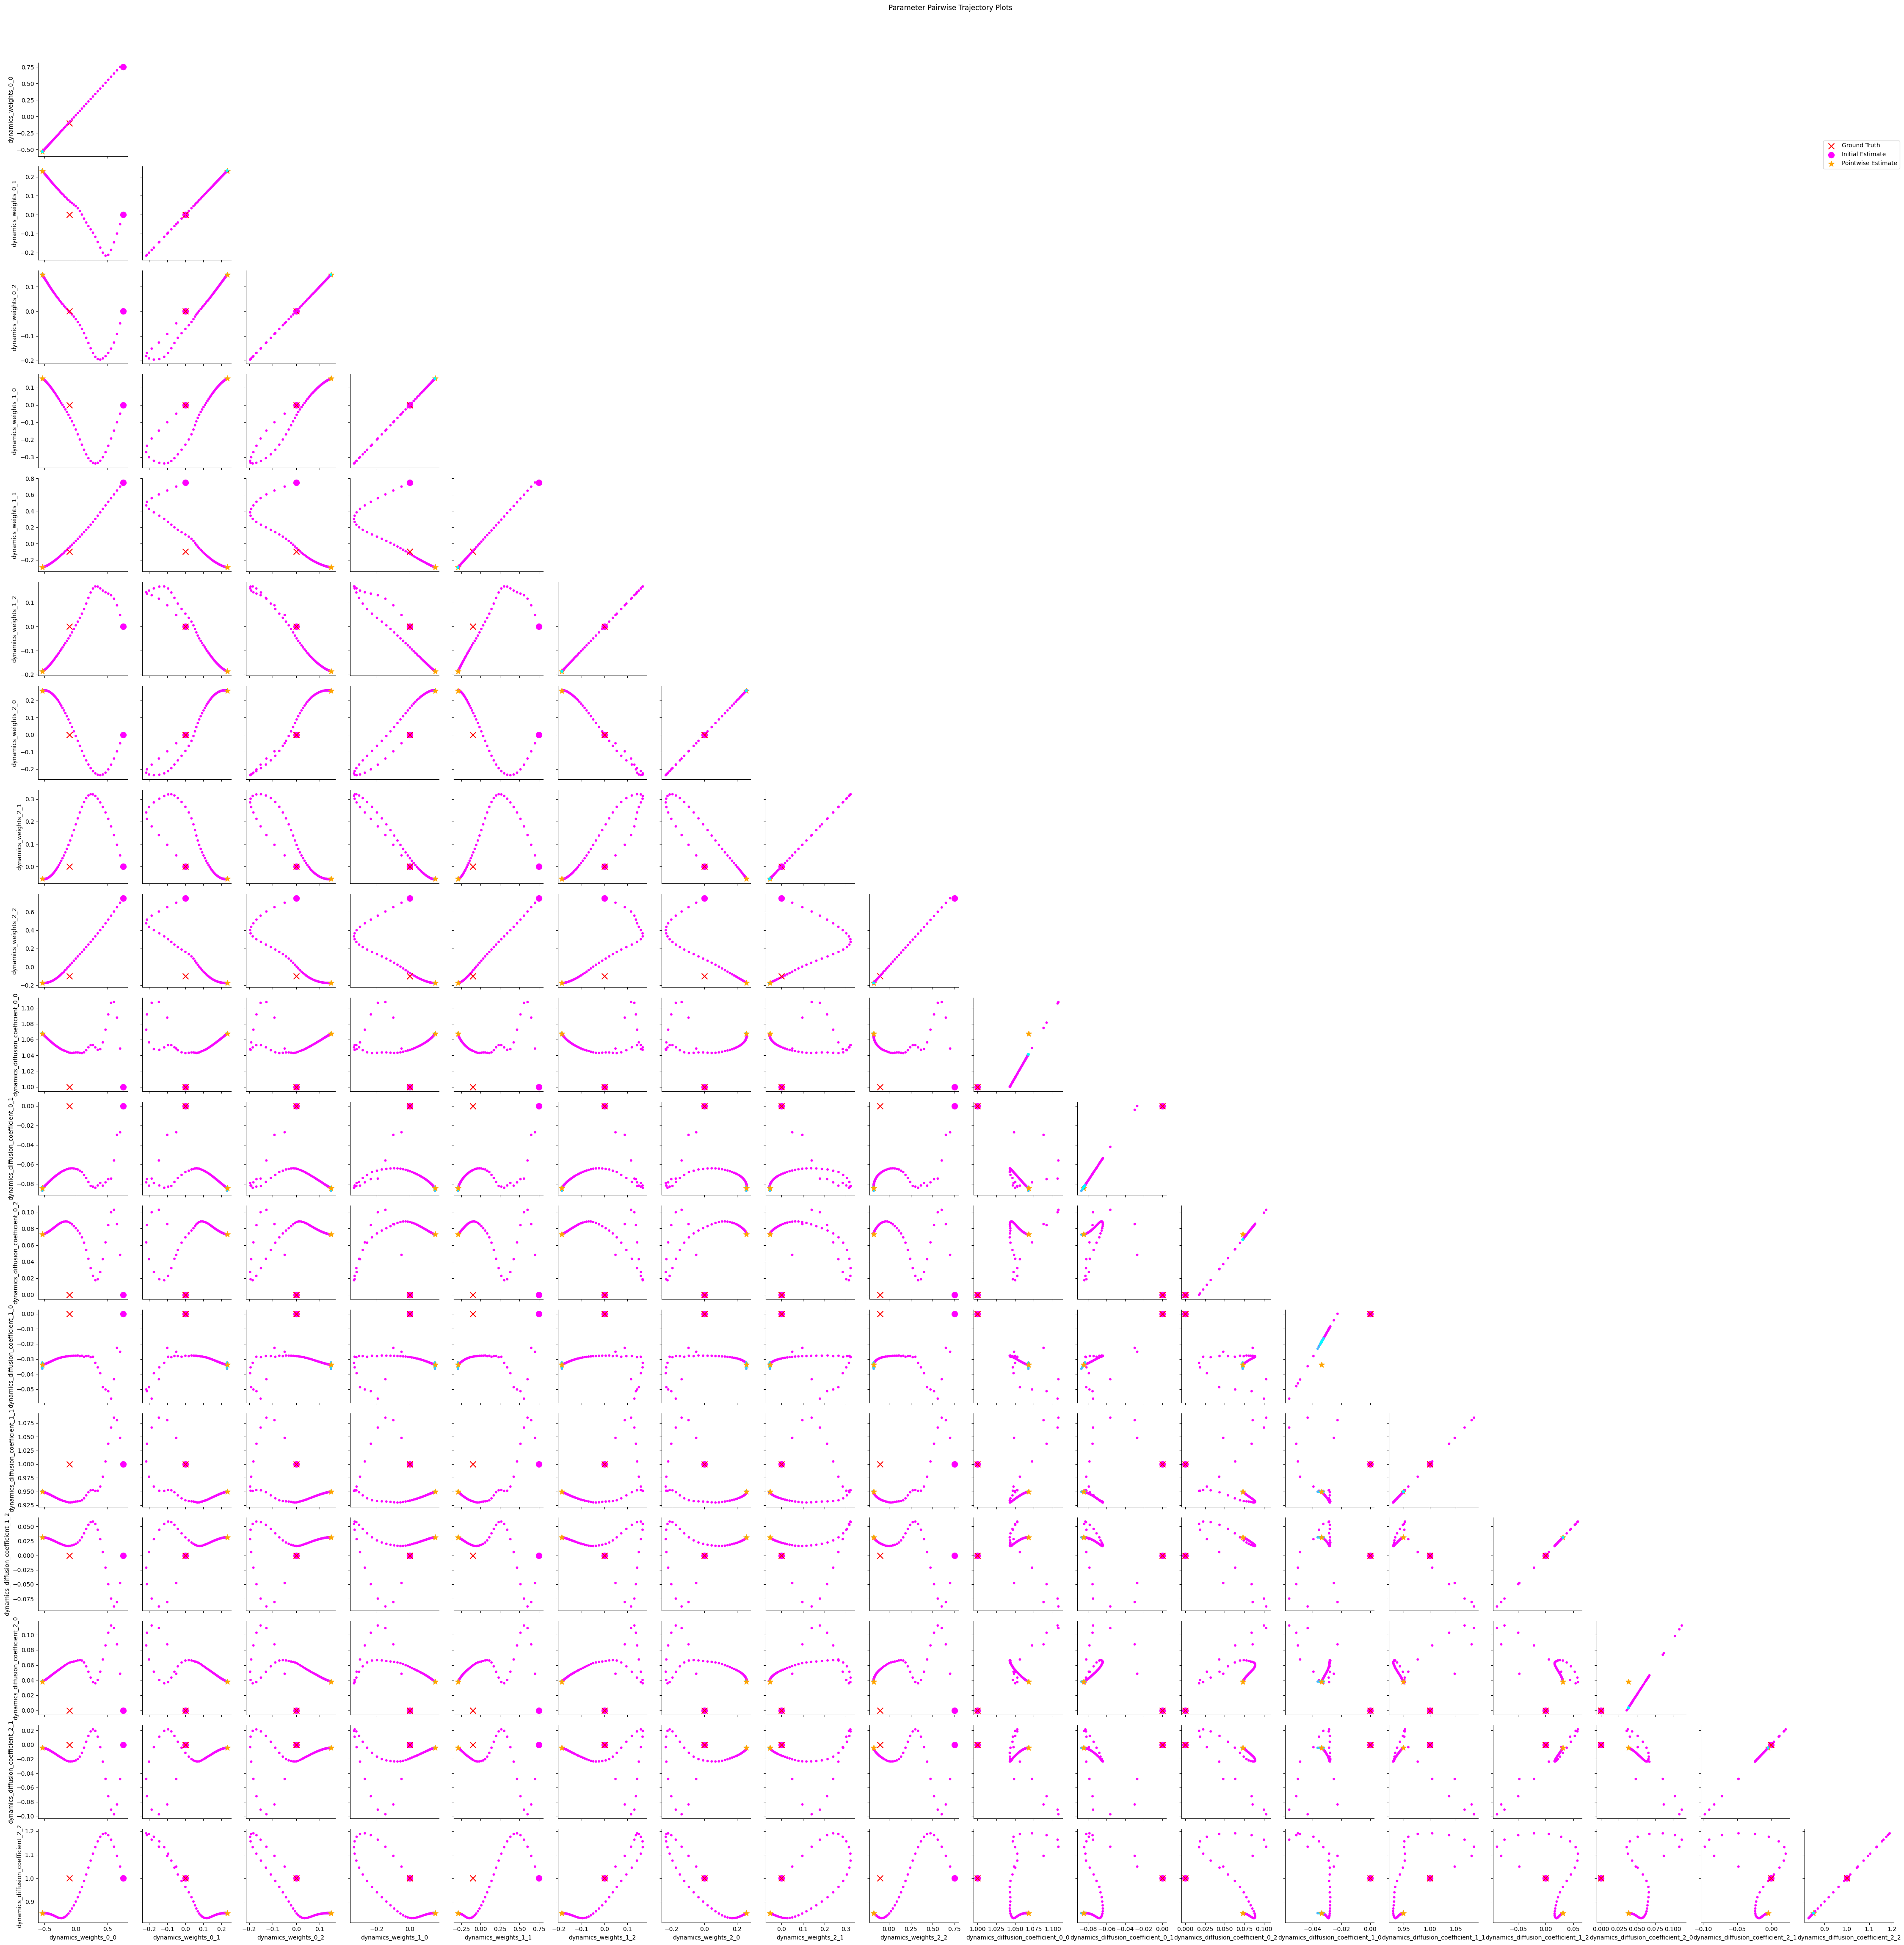

In [31]:
# Plot parameter trajectories over SGD iterations ---translating trees to dataframes
plot_param_sequences(
    param_history=learnable_params_to_1d_df(
        new_sgd_fitted_params_history, new_learnable_props, has_batch_dim=True
    ),
    true=learnable_params_to_1d_df(
        true_params, new_learnable_props
    ),
    init=learnable_params_to_1d_df(
        new_learnable_params, new_learnable_props
    ),
    pointwise_estimate=learnable_params_to_1d_df(
        new_sgd_fitted_params, new_learnable_props
    ),
    burn_in_frac=0.0,
    pairwise_plots=True,
    plot_save_path=None # Plot here instead of saving
)

Different t_emissions for all data-streams

In [32]:
# If we want to have different emission times for each new data-stream

# Pick num_data_streams different keys
t_emissions_keys = jax.random.split(next(keys), num_data_streams)

# Sample different emission times for each data-stream, using vamp
# t_emissions shape will be (num_data_streams, num_timesteps)
batch_t_emissions = vmap(
        sample_t_emissions,
        in_axes=(None, None, None, None, 0, None)
    )(
        0.0, # start=0.0,
        25.0, #stop=25.0,
        0.01, # dt=0.01,
        False, # regular=False,
        t_emissions_keys,
        False, # check = False
)

num_timesteps = batch_t_emissions.shape[1]

# Simulate data using true parameters (observed at times t_emissions)
# Again using vmap over the model.sample method
# Pick num_data_streams different keys
sample_keys = jax.random.split(next(keys), num_data_streams)
# states shape will be (num_data_streams, num_timesteps, state_dim)
# emissions shape will be (num_data_streams, num_timesteps, emission_dim)
batch_states, batch_emissions = vmap(
        true_model.sample,
        in_axes=(None, 0, None, 0)
    )(
    true_params, # params=true_params,
    sample_keys,
    num_timesteps,
    batch_t_emissions
)

Sampling from CD distributions: this may be a poor approximation if you're simulating from a non-linear SDE. It is a highly appropriate choice for linear SDEs.
Sampling from continuous-discrete linear Gaussian SSM distributions


In [33]:
# Compute log-likelihood of the batch data under the true model
batch_lls = vmap(
    true_model.marginal_log_prob,
    in_axes=(None, 0, 0, None)
    )(
        true_params,
        batch_emissions,
        batch_t_emissions,
        kf_hyperparams,
)
print("Per-data-stream log-likelihoods under the true model:", batch_lls)
print("Total log-likelihood under the true model:", batch_lls.sum())
print("Total average log-likelihood under the true model:", batch_lls.mean())

Per-data-stream log-likelihoods under the true model: [-2516.72845158 -2664.12896332 -2553.15492171 -2517.65972602
 -2643.53843939]
Total log-likelihood under the true model: -12895.21050201216
Total average log-likelihood under the true model: -2579.042100402432


Learnable model for the batched data

In [34]:
# Create and initialize a new CD-NLGSSM model for the batched data
new_learnable_model, new_learnable_params, new_learnable_props = create_cddynamax_model_from_config(
    config_path=config_path,
    true_model_config_file=learnable_cdlgssm_config_model,
    overrides=learnable_cdlgssm_model_def,
)

In [35]:
# Run SGD for parameter estimation
import optax
if 'sgd' in optim_configs:
    # SGD configuration
    sgd_config = config['sgd']
    # SGD MAP estimation via the cd-dynamax learnable_model's fit_sgd method
    print("\nStarting SGD fitting...")
    new_fit_results = new_learnable_model.fit_sgd(
        initial_params = new_learnable_params,
        props=new_learnable_props,
        emissions=batch_emissions, # Use batched emissions
        t_emissions=batch_t_emissions, # Use batched t_emissions
        filter_hyperparams=kf_hyperparams,
        inputs=None,
        optimizer=eval(sgd_config.get('optimizer', 'optax.adam(1e-3)')),
        batch_size = sgd_config.getint('batch_size', 1),
        num_epochs = sgd_config.getint('num_epochs', 50),
        shuffle = sgd_config.getboolean('shuffle', False),
        return_param_history = sgd_config.getboolean('return_param_history', False),
        return_grad_history = sgd_config.getboolean('return_grad_history', False),
        key = jr.PRNGKey(sgd_config.getint('key', 0))
    )


Starting SGD fitting...


Organize results for easier plotting

In [36]:
# First element of tuple is the fitted parameters
new_sgd_fitted_params=new_fit_results[0]
# Note that fit_sgd returns normalized negative log-likelihoods
# So we multiply it by the number of datapoints in emissions
new_sgd_loss_history=-new_fit_results[1] * batch_emissions.size

# Process history outputs if requested
if sgd_config.getboolean('return_param_history', False) and sgd_config.getboolean('return_grad_history', False):
    new_sgd_fitted_params_history=new_fit_results[2]
    new_sgd_fitted_grad_history=new_fit_results[3]
elif sgd_config.getboolean('return_param_history', False) :
    new_sgd_fitted_params_history=new_fit_results[2]
elif sgd_config.getboolean('return_grad_history', False):
    new_sgd_fitted_grad_history=new_fit_results[2]

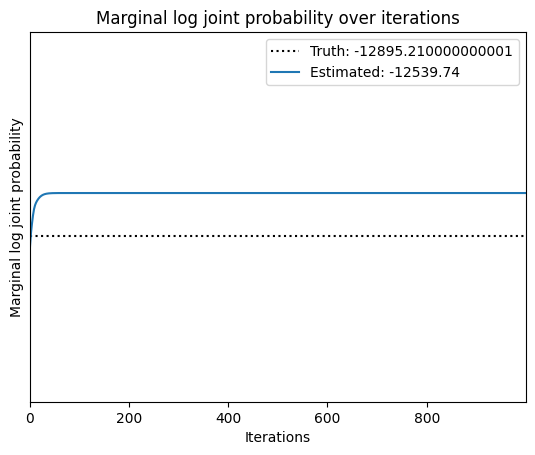

In [37]:
# Plot the marginal log likelihood learning curve
plot_mll_learning_curve(
    true_model = true_model,
    true_params = true_params,
    true_emissions = batch_emissions,
    t_emissions = batch_t_emissions,
    marginal_lls = new_sgd_loss_history,
    filter_hyperparams=kf_hyperparams,
    plot_save_path=None # Plot here instead of saving
)

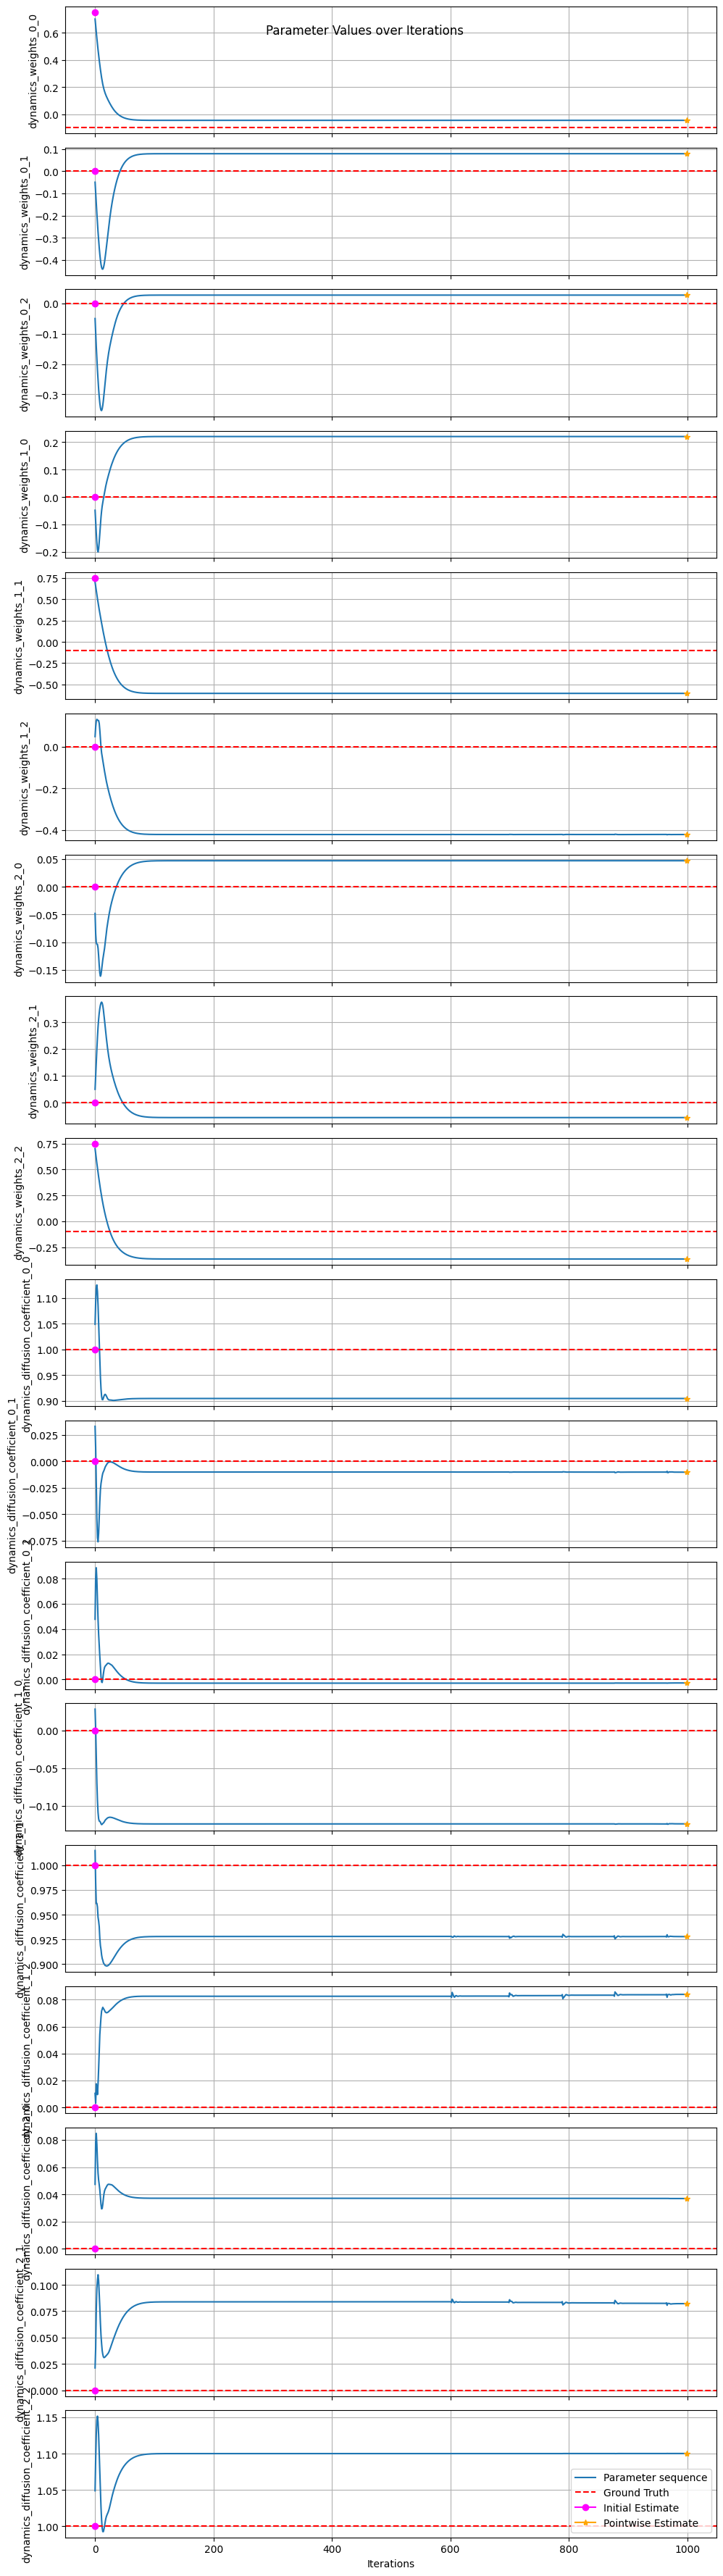

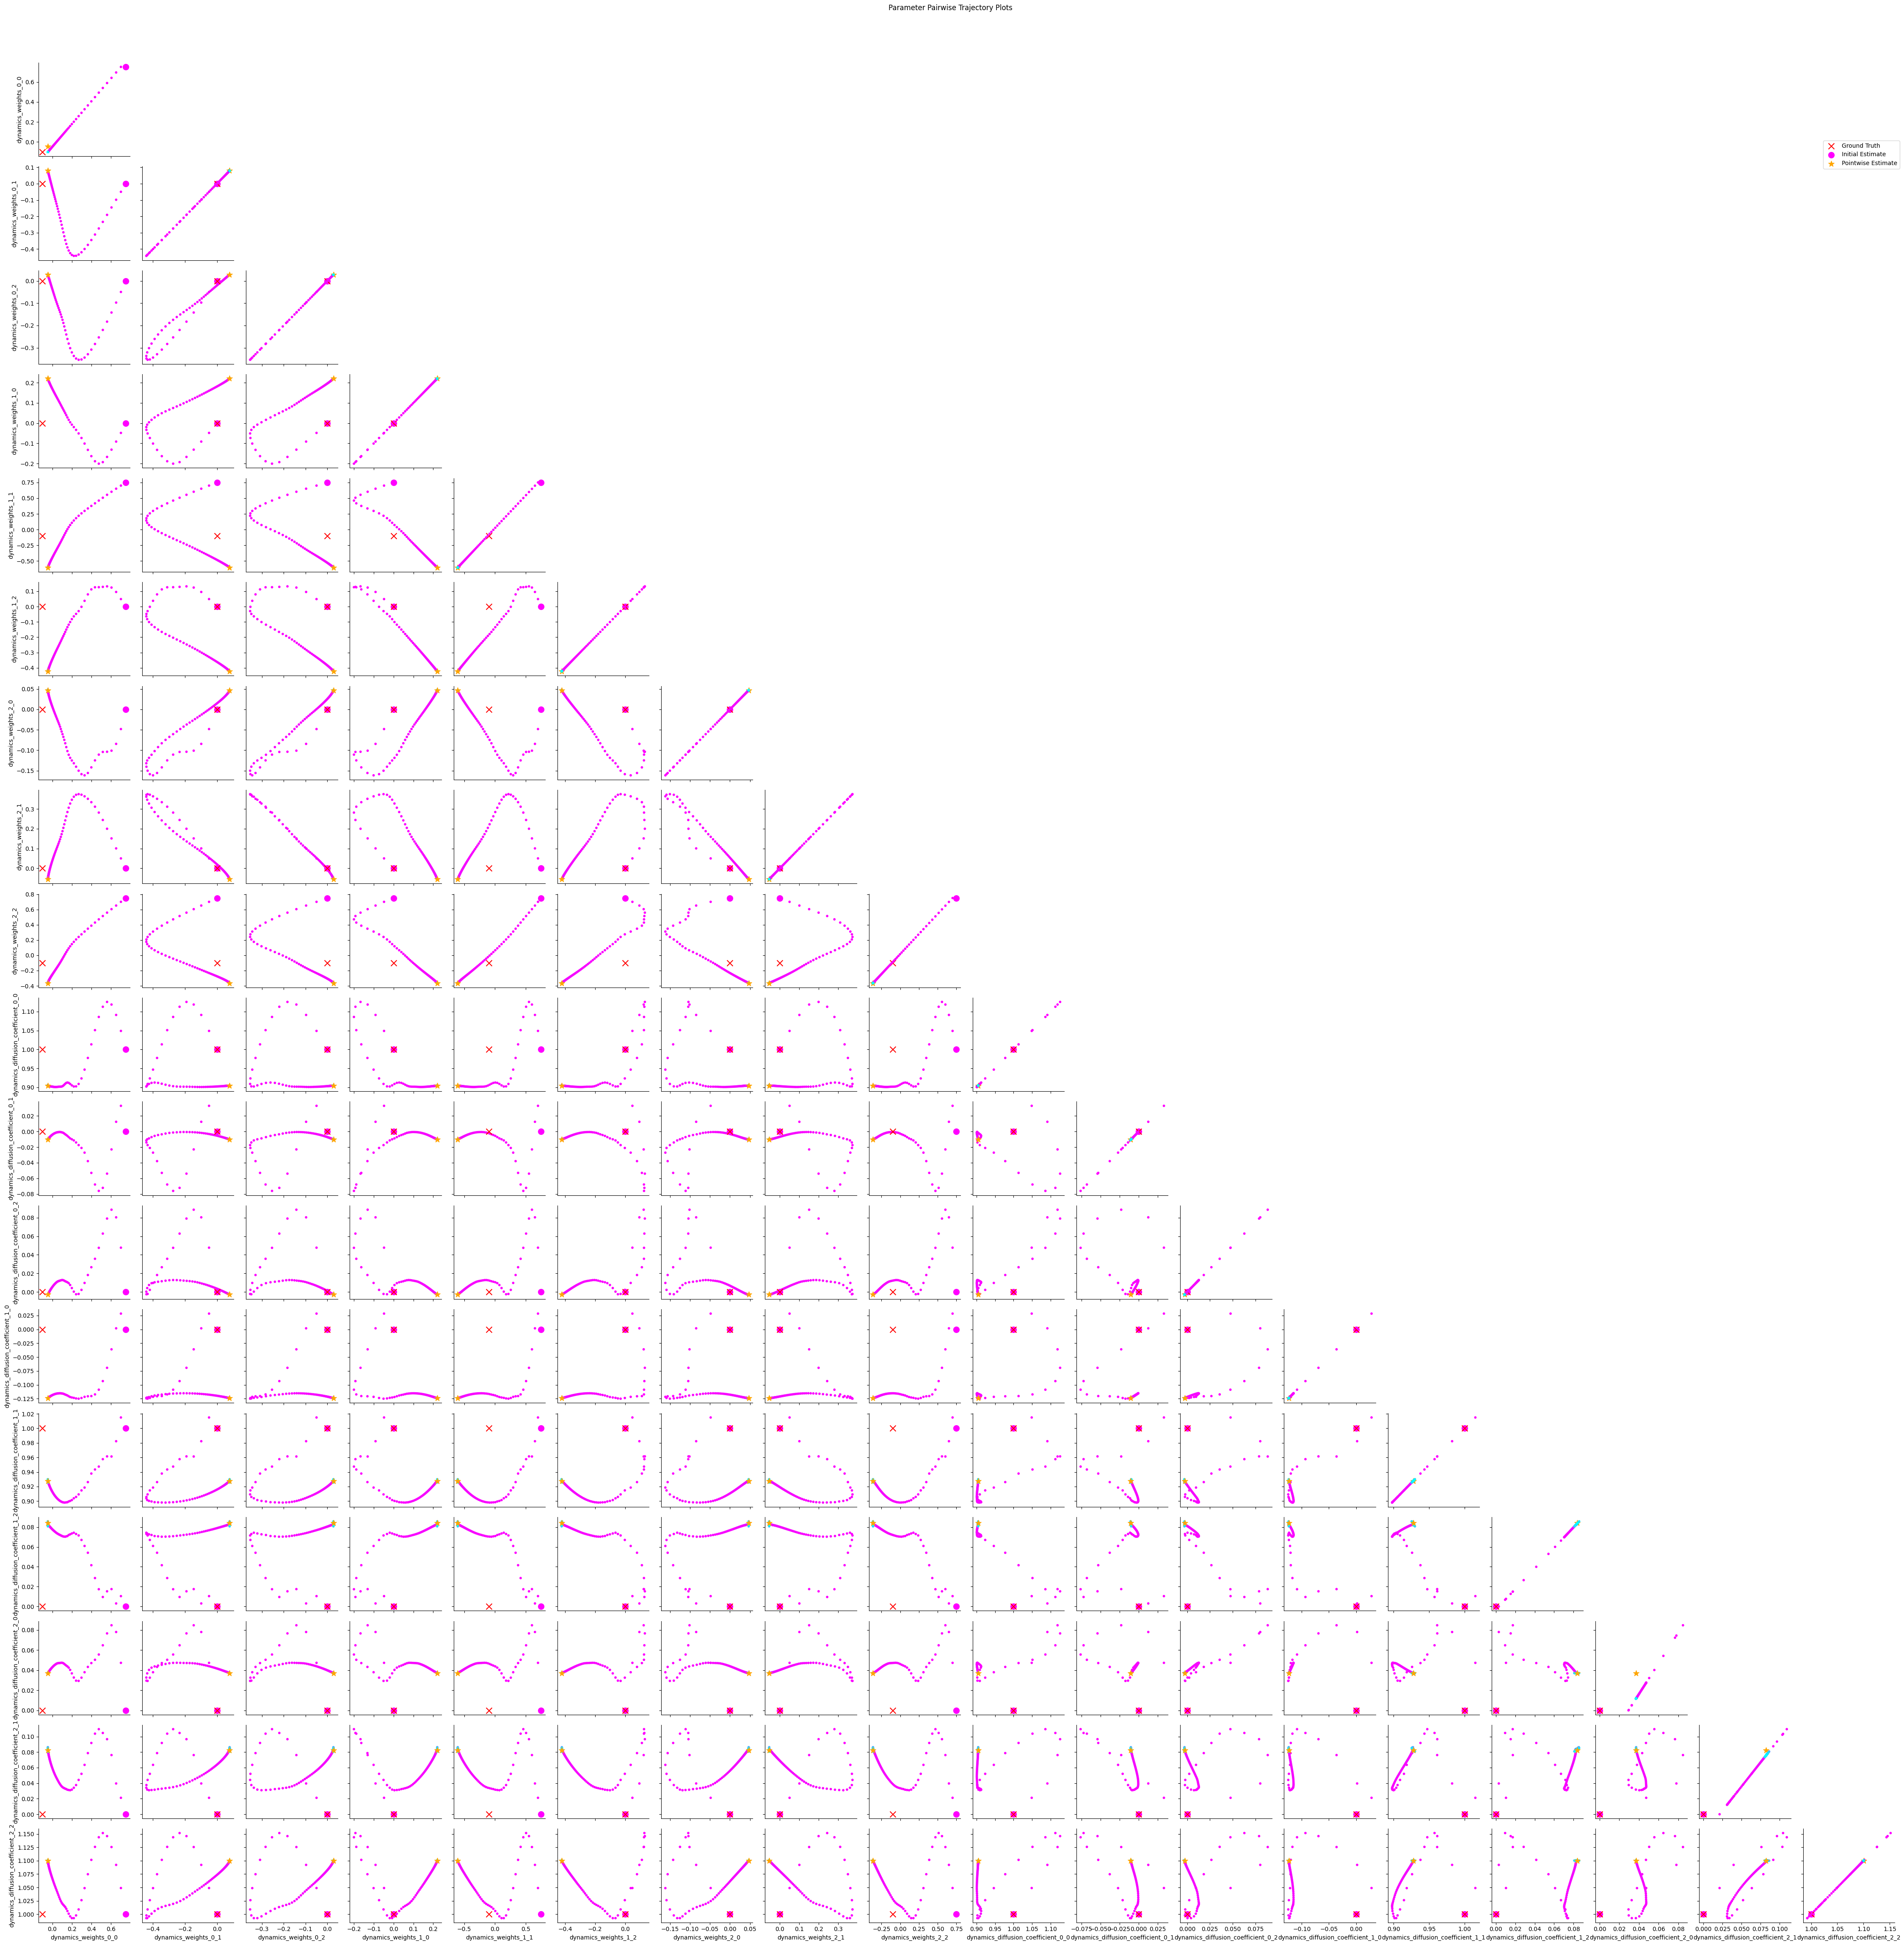

In [38]:
# Plot parameter trajectories over SGD iterations ---translating trees to dataframes
plot_param_sequences(
    param_history=learnable_params_to_1d_df(
        new_sgd_fitted_params_history, new_learnable_props, has_batch_dim=True
    ),
    true=learnable_params_to_1d_df(
        true_params, new_learnable_props
    ),
    init=learnable_params_to_1d_df(
        new_learnable_params, new_learnable_props
    ),
    pointwise_estimate=learnable_params_to_1d_df(
        new_sgd_fitted_params, new_learnable_props
    ),
    burn_in_frac=0.0,
    pairwise_plots=True,
    plot_save_path=None # Plot here instead of saving
)